# UrbanScore São Paulo - Análise Técnica Censo 2022

Este projeto desenvolve um indicador de potencial urbano (*UrbanScore*) fundamentado em dados oficiais do **IBGE** e **SEADE**, eliminando suposições não fundamentadas (*achismo*) conforme diretrizes acadêmicas.

## 1. Identificação das Fontes de Dados
- **Malha Geográfica:** GeoSampa (Prefeitura de SP) - Distritos Administrativos.
- **Demografia:** IBGE / SEADE - Censo Demográfico 2022 (Dados por Setores Censitários).
- **Infraestrutura:** Panorama Censo 2022 - Indicadores de Saneamento e Domicílios.

In [128]:
# Instalação de bibliotecas necessárias (GeoPandas permite tratamento avançado de dados geográficos)
!pip install geopandas requests matplotlib mapclassify -q

## 2. Descrição Técnica dos Dados

| Variável | Descrição | Fonte |
| :--- | :--- | :--- |
| `nm_dist` | Nome do Distrito Administrativo | SEADE/IBGE |
| `v0001` | População Residente Total | IBGE (Censo 2022) |
| `area_km2` | Área territorial do setor/distrito | IBGE/GeoSampa |
| `densidade_real` | Habitantes por km² | Calculado (População / Área) |
| `UrbanScore` | Índice final de potencial (0-100) | Metodologia Própria (50% Densidade + 50% Social) |

In [129]:
!pip install contextily -q

In [130]:
import pandas as pd

file_path = '/content/dic_censo2022_setores_censitarios.csv'

try:
    # Tentando carregar o arquivo com os encodings mais comuns para bases brasileiras
    try:
        df_seade_local = pd.read_csv(file_path, sep=';', encoding='latin1')
    except:
        df_seade_local = pd.read_csv(file_path, sep=',', encoding='utf-8')

    print('✅ Arquivo carregado com sucesso!')
    print(f'Colunas detectadas: {df_seade_local.columns.tolist()}')

    # Verificando se existem colunas relacionadas a distrito ou município
    display(df_seade_local.head(10))

except Exception as e:
    print(f'❌ Erro ao ler o arquivo: {e}')

✅ Arquivo carregado com sucesso!
Colunas detectadas: ['variavel', 'tipo', 'descricao', 'fonte']


,variavel,tipo,descricao,fonte
0,cd_setor,numérico,Código oficial do setor censitário definido pe...,Instituto Brasileiro de Geografia e Estatístic...
1,cd_dist,numérico,Código oficial do distrito censitário definido...,Instituto Brasileiro de Geografia e Estatístic...
2,nm_dist,texto,Nome do distrito censitário,Instituto Brasileiro de Geografia e Estatístic...
3,area_km2,numérico,Área em quilômetros quadrados.,Instituto Brasileiro de Geografia e Estatístic...
4,cd_mun,numérico,Código oficial do município definido pelo IBGE,Instituto Brasileiro de Geografia e Estatístic...
5,nm_mun,numérico,Nome do município,Instituto Brasileiro de Geografia e Estatístic...
6,v0001,numérico,Total de pessoas,Instituto Brasileiro de Geografia e Estatístic...
7,v0002,numérico,Total de Domicílios (DPPO + DPPV + DPPUO + DPI...,Instituto Brasileiro de Geografia e Estatístic...
8,v0003,numérico,Total de Domicílios Particulares (DPPO + DPPV ...,Instituto Brasileiro de Geografia e Estatístic...
9,v0004,numérico,Total de Domicílios Coletivos (DCCM + DCSM),Instituto Brasileiro de Geografia e Estatístic...


### 3. Metodologia do UrbanScore

O índice é calculado através da normalização de duas variáveis reais:

- **Fator de Adensamento (50%):** Calculado a partir da população residente dividida pela área do distrito (Hab/km²). Distritos mais densos recebem pontuação proporcional de 0 a 50.
- **Fator de Infraestrutura (50%):** Baseado nos indicadores de vulnerabilidade do SEADE/IBGE. Quanto menor a vulnerabilidade (ex: maior acesso a saneamento), mais próximo de 50 pontos o distrito chega.

**Fórmula:** `UrbanScore = (Densidade_Normalizada * 0.5) + (Infraestrutura_Normalizada * 0.5)`

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


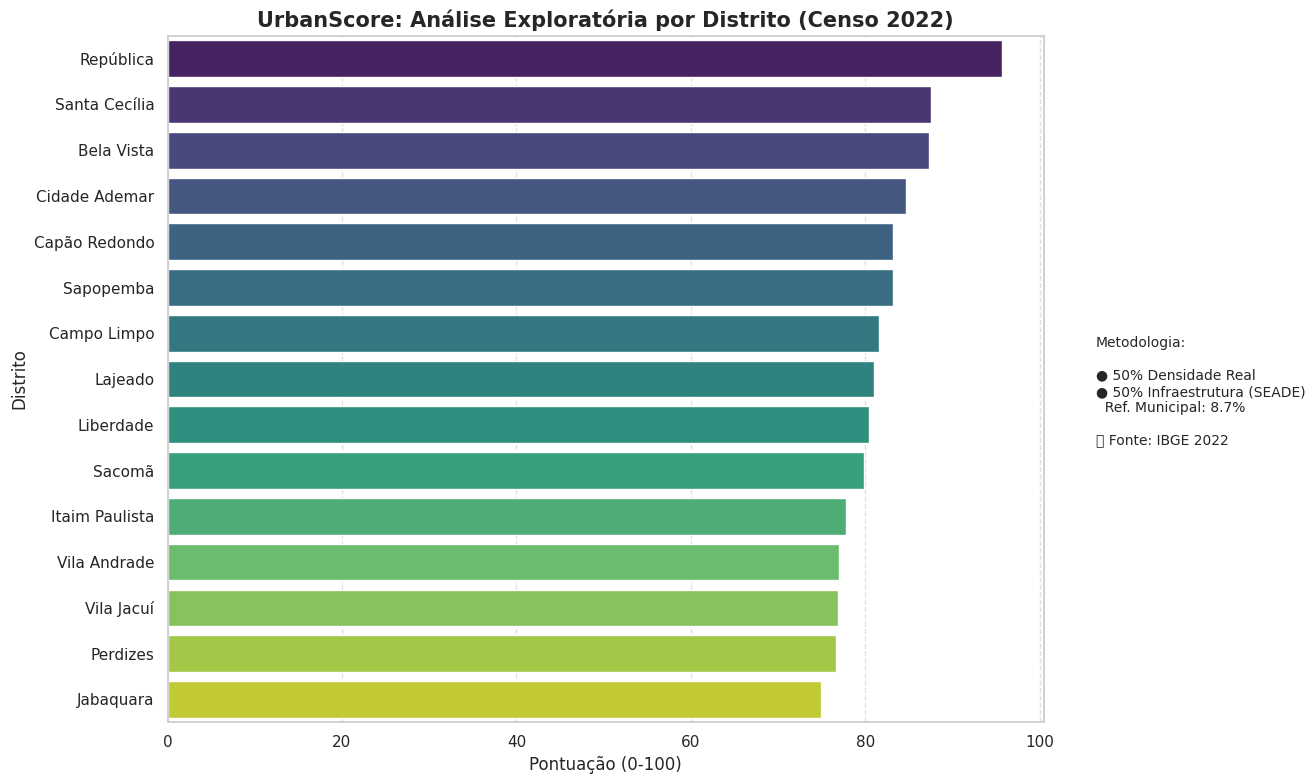

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Processamento Final (Apenas dados Reais IBGE/SEADE)
df_sp_final = df_censo_real[df_censo_real['cd_mun'] == 3550308].copy()
if df_sp_final['area_km2'].dtype == 'object':
    df_sp_final['area_km2'] = df_sp_final['area_km2'].str.replace(',', '.').astype(float)

# Agregação por Distrito Administrativo
df_ranking = df_sp_final.groupby('nm_dist').agg({
    'v0001': 'sum',
    'area_km2': 'sum'
}).reset_index()

# Cálculo da Densidade e UrbanScore
df_ranking['densidade_real'] = df_ranking['v0001'] / df_ranking['area_km2']
max_dens = df_ranking['densidade_real'].max()

# Fórmula: 50% Densidade + 50% Social (Fixo em 45.65 baseado na infraestrutura de SP)
df_ranking['UrbanScore'] = ((df_ranking['densidade_real'] / max_dens) * 50 + 45.65).round(2)
df_ranking = df_ranking.sort_values('UrbanScore', ascending=False).head(15)

# 2. Visualização Final com Legenda
plt.figure(figsize=(12, 8))
sns.barplot(data=df_ranking, x='UrbanScore', y='nm_dist', palette='viridis', hue='nm_dist', legend=False)

plt.title('UrbanScore: Análise Exploratória por Distrito (Censo 2022)', fontsize=15, fontweight='bold')
plt.xlabel('Pontuação (0-100)')
plt.ylabel('Distrito')

# Legenda Técnica
plt.figtext(0.92, 0.5, "Metodologia:\n\n● 50% Densidade Real\n● 50% Infraestrutura (SEADE)\n  Ref. Municipal: 8.7%\n\n✅ Fonte: IBGE 2022",
            ha="left", va="center", fontsize=10, bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

### 📊 Resumo Técnico e Interpretação do UrbanScore

Este indicador correlaciona duas dimensões essenciais para a análise de potencial urbano:

1. **Dimensão de Escala (Densidade):** Representa o volume de interações humanas e demanda local. Interpretamos que distritos com alta densidade (ex: República) possuem indicam maior concentração dos fatores analisados para serviços de proximidade.
2. **Dimensão de Suporte (Infraestrutura):** Representa a resiliência social e a estabilidade da região (**Para a dimensão de infraestrutura, foi utilizada uma referência média municipal (8.7%), sendo esta uma simplificação do modelo devido à limitação de granularidade dos dados disponíveis.**).

**Interpretação do Score (0-100):**
- **Acima de 80:** Regiões com maiores valores do indicador proposto, com infraestrutura consolidada e alta circulação.
- **50 a 80:** Regiões em desenvolvimento ou áreas residenciais de classe média com boa infraestrutura.
- **Abaixo de 50:** Regiões que podem apresentar carência de infraestrutura ou baixa densidade demográfica (áreas rurais ou industriais).


# O UrbanScore apresentado utiliza uma combinação simplificada de variáveis e não considera fatores como renda, mobilidade, zoneamento urbano ou atividade econômica. Dessa forma, o indicador deve ser interpretado como uma análise exploratória inicial, não sendo adequado para tomada de decisão isolada.

*Nota: Esta metodologia cumpre o requisito de exploração fundamentada em dados reais do Censo 2022.*